In [2]:
import utils
from tqdm import tqdm
import matplotlib as mpl
import matplotlib.pyplot as plt
import pefile
import numpy as np

mpl.rcParams["figure.dpi"] = 300

dataset = utils.data.MalwareDataset()

In [3]:
def get_size(path):
    try:
        pe = pefile.PE(path, fast_load=True)
        size = pe.dump_dict()["OPTIONAL_HEADER"]["SizeOfCode"]["Value"]
        return size
    except:
        return 0

In [4]:
malware_size = []
benign_size = []

for path, label in tqdm(dataset):
    size = get_size(path)
    if label == 0:
        benign_size.append(size)
    else:
        malware_size.append(size)

100%|██████████| 11115/11115 [07:06<00:00, 26.08it/s] 


In [5]:
malware_size = np.array(malware_size)
benign_size = np.array(benign_size)

print(f"Min: {malware_size.min()}, Max: {malware_size.max()}, No: {len(malware_size)}")
print(f"Min: {benign_size.min()}, Max: {benign_size.max()}, No: {len(benign_size)}")

Min: 0, Max: 1766614113, No: 5792

Min: 0, Max: 502944256, No: 5323

Text(0.5, 0, 'Executable Kind')

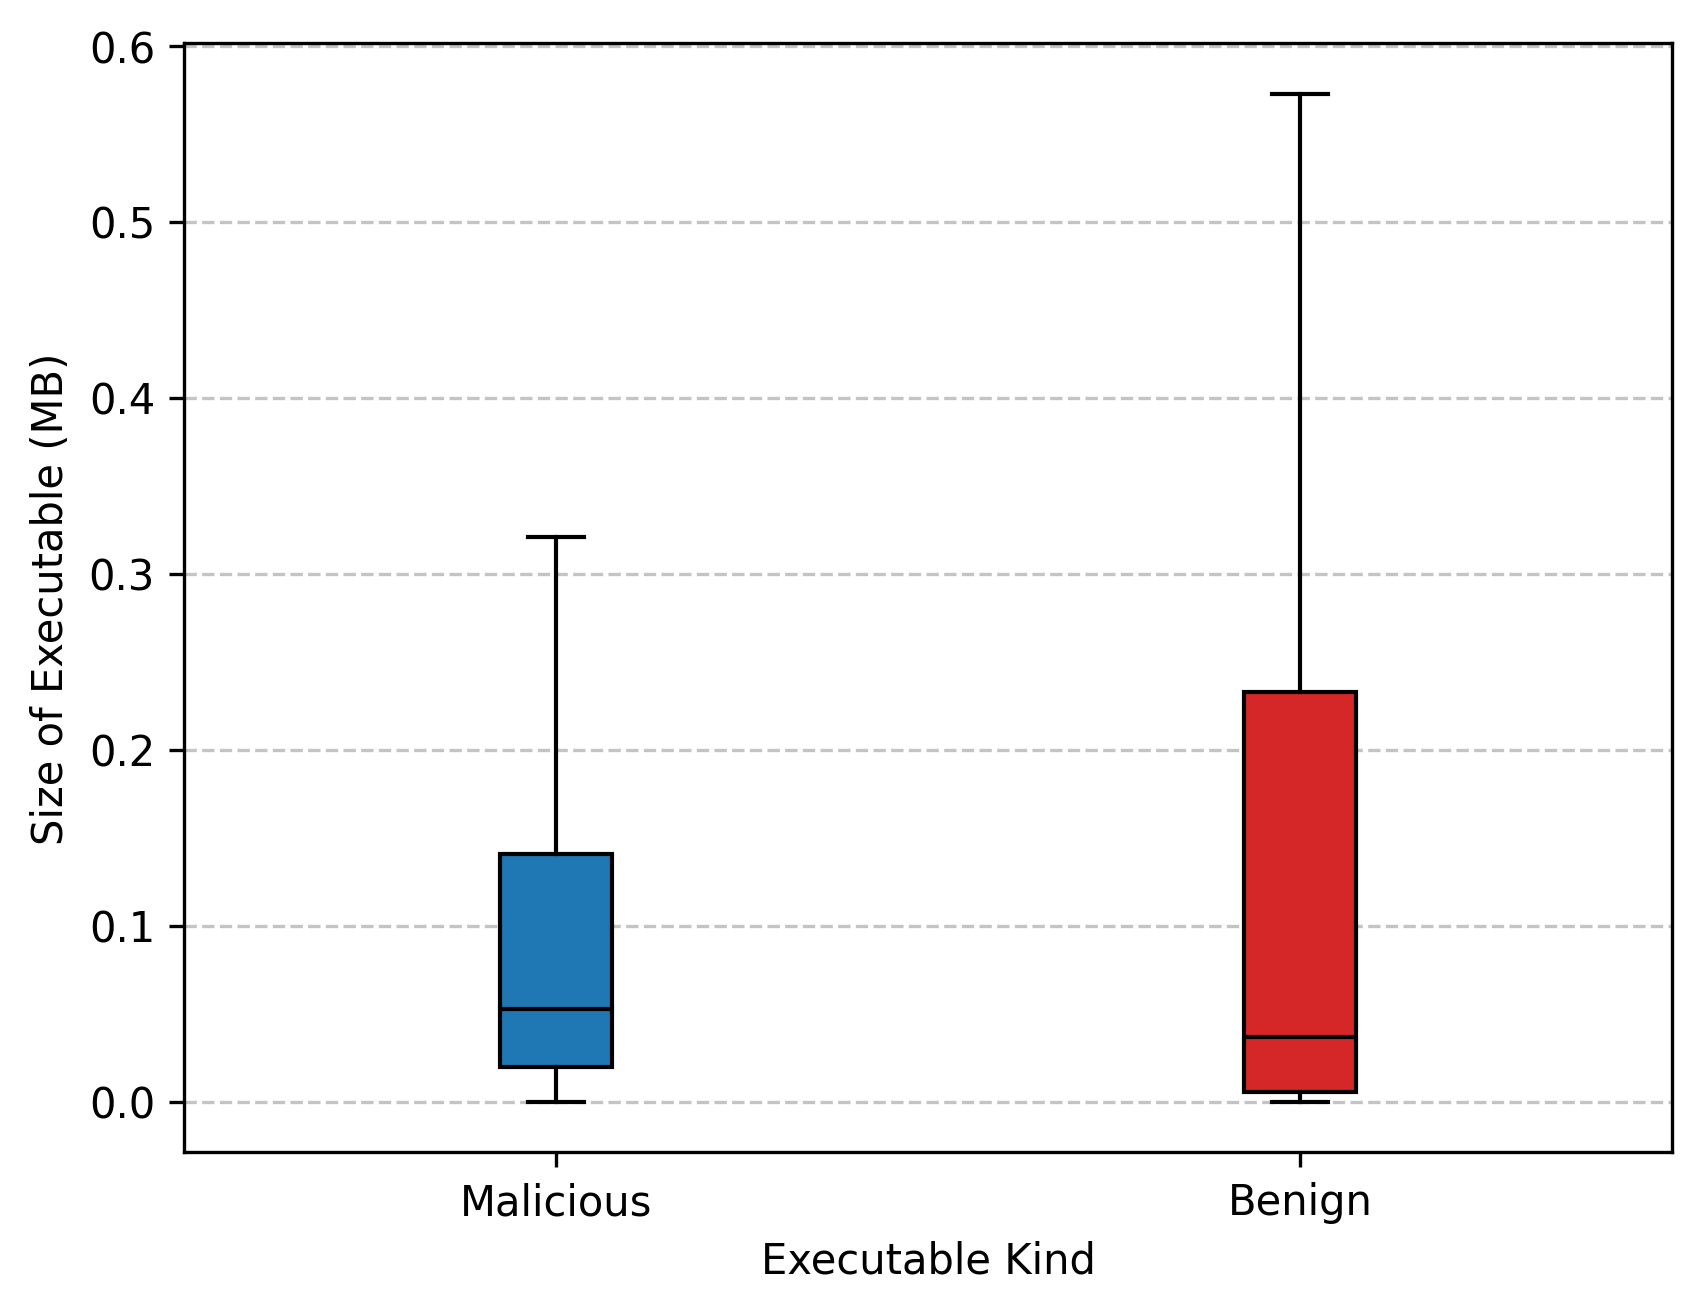

In [ ]:
# bp = plt.boxplot(
#     [malware_size / 1024**2, benign_size / 1024**2],
#     vert=True,
#     patch_artist=True,
#     tick_labels=["Malicious", "Benign"],
#     medianprops={"color": "black"},
#     sym="",
# )

# for box, color in zip(bp["boxes"], ["tab:blue", "tab:red"]):
#     box.set(facecolor=color)
# plt.grid(axis="y", linestyle="--", alpha=0.75)
# plt.ylabel("Size of Executable (MB)")
# plt.xlabel("Executable Kind")

In [ ]:
import pandas as pd

df = pd.DataFrame(
    {
        "label": [0] * len(benign_size) + [1] * len(malware_size),
        "size": np.array(benign_size.tolist() + malware_size.tolist()) / (1024**2),
    }
)

Text(0.5, 0, 'Executable Kind')

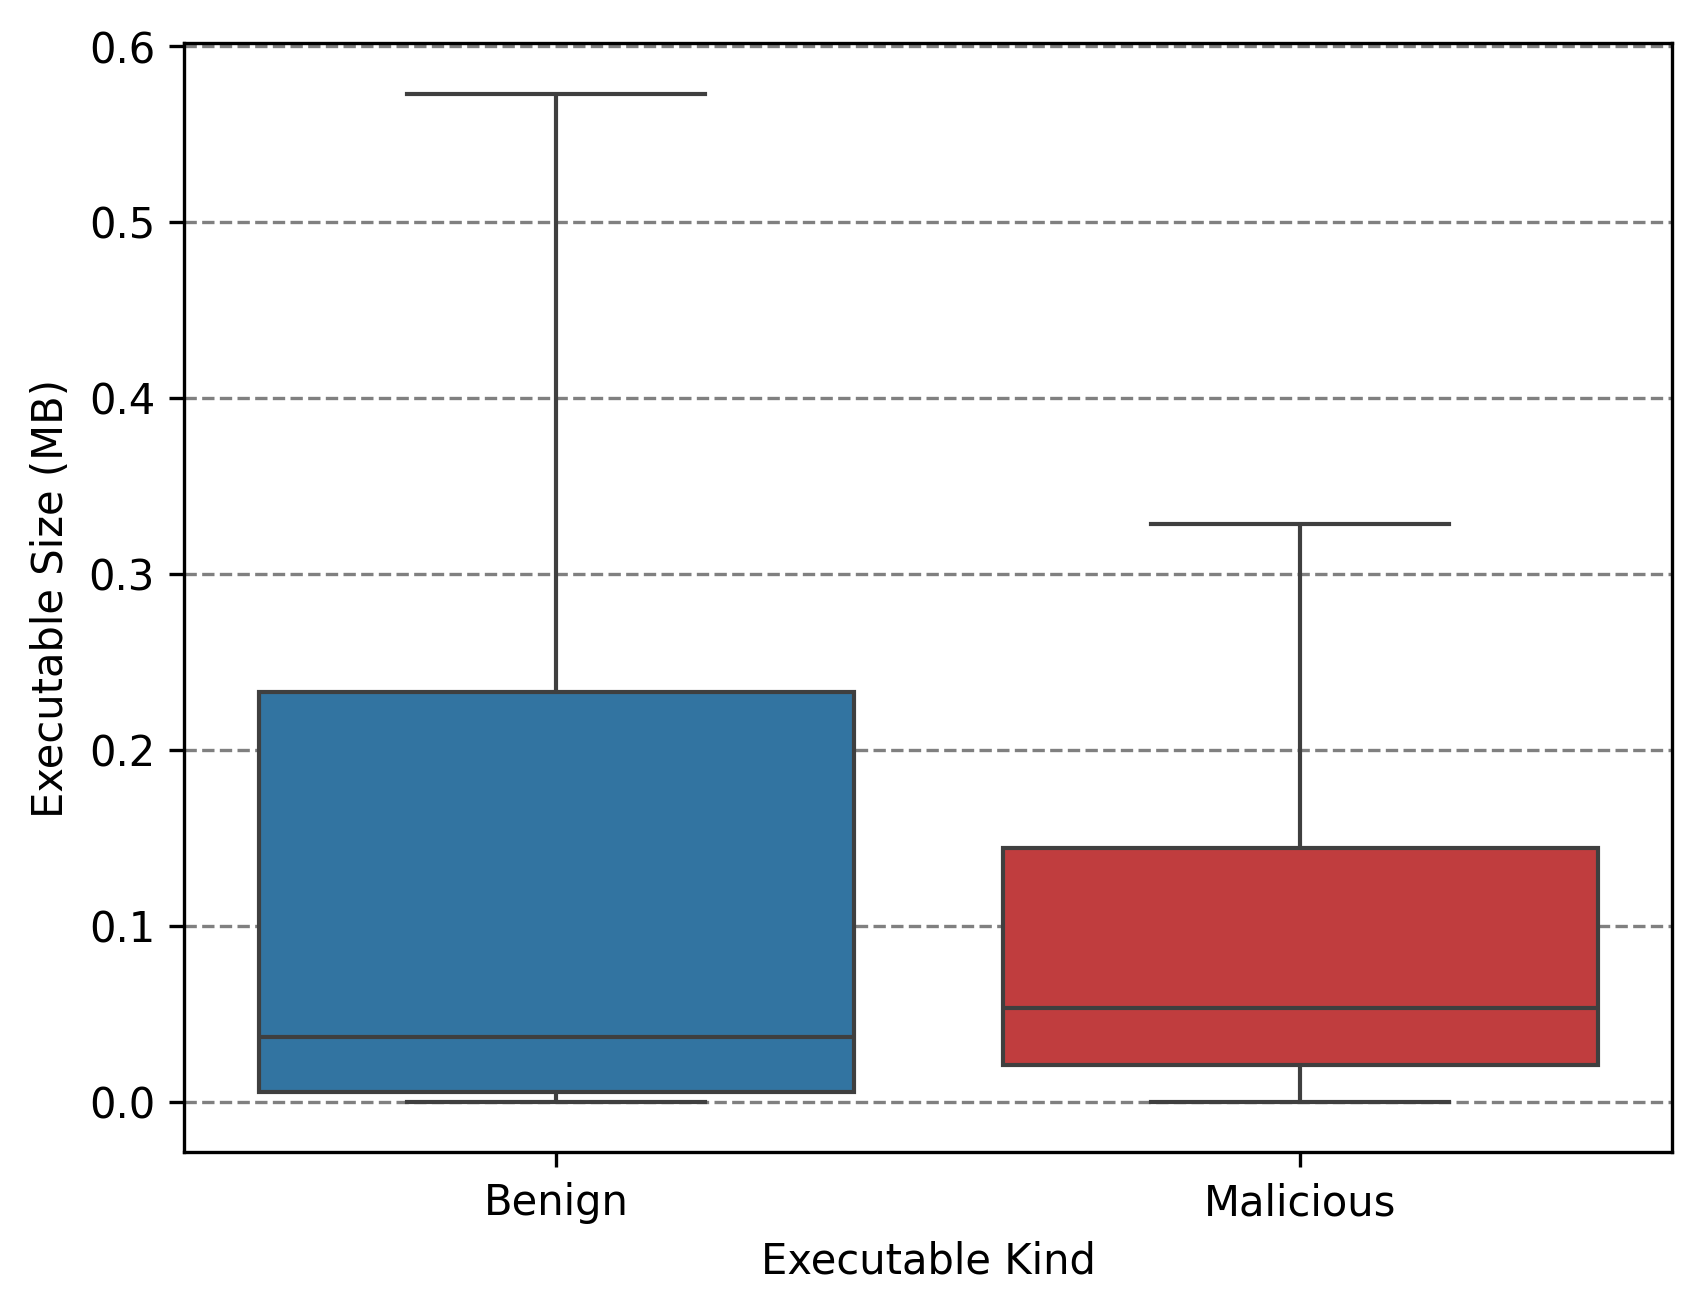

In [ ]:
import seaborn as sns

fig, ax = plt.subplots(dpi=300)

sns.boxplot(
    data=df,
    x="label",
    hue="label",
    palette={
        np.int64(0): "tab:blue",
        np.int64(1): "tab:red",
    },
    y="size",
    showfliers=False,
    formatter=lambda l: "Benign" if l == 0 else "Malicious",
    # log_scale=True,
    legend=False,
    ax=ax,
)
ax.grid(True, axis="y", linestyle="--", c="grey")
ax.set_ylabel("Executable Size (MB)")
ax.set_xlabel("Executable Kind")